In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

from gradient_boosting import GradientBoostingRegressor, GradientBoostingClassifier

In [2]:
rng = np.random.default_rng(42)
X_reg = np.sort(rng.uniform(0, 10, 300)).reshape(-1, 1)
y_reg = np.sin(X_reg).ravel() + rng.normal(0, 0.15, X_reg.shape[0])

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

gbr = GradientBoostingRegressor(n_estimators=150, lr=0.1, max_depth=2, subsample=1.0, random_state=42)
gbr.fit(Xr_train, yr_train)

preds = gbr.predict(Xr_test)
print(f"MSE: {mean_squared_error(yr_test, preds):.3f}")
print(f"R2:  {r2_score(yr_test, preds):.3f}")

MSE: 0.037
R2:  0.917


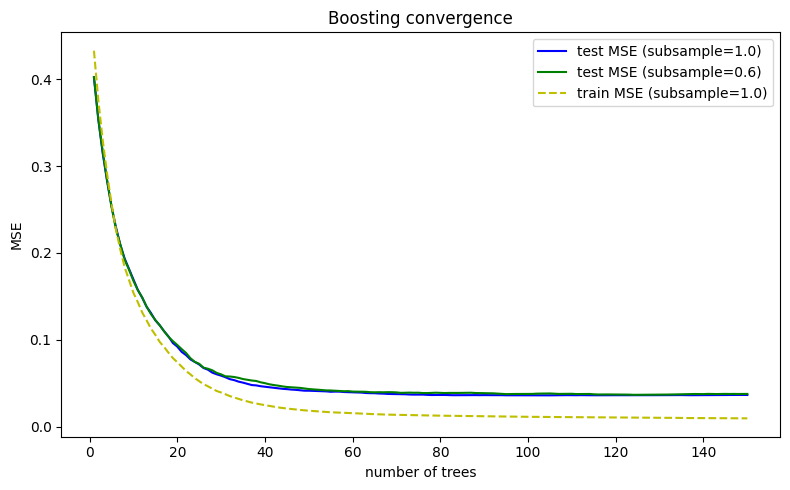

In [3]:
def staged_mse(model, X_tr, y_tr, X_te, y_te):
    cum_train = np.full(len(y_tr), model._initial_prediction)
    cum_test = np.full(len(y_te), model._initial_prediction)
    train_mse, test_mse = [], []
    for tree in model.trees:
        cum_train = cum_train + model.lr * tree.predict(X_tr)
        cum_test = cum_test + model.lr * tree.predict(X_te)
        train_mse.append(mean_squared_error(y_tr, cum_train))
        test_mse.append(mean_squared_error(y_te, cum_test))
    return train_mse, test_mse

gbr_sub = GradientBoostingRegressor(n_estimators=150, lr=0.1, max_depth=2, subsample=0.6, random_state=42)
gbr_sub.fit(Xr_train, yr_train)

train_mse_full, test_mse_full = staged_mse(gbr, Xr_train, yr_train, Xr_test, yr_test)
train_mse_sub, test_mse_sub = staged_mse(gbr_sub, Xr_train, yr_train, Xr_test, yr_test)

n_trees = np.arange(1, len(train_mse_full) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_trees, test_mse_full, color="b", label="test MSE (subsample=1.0)")
ax.plot(n_trees, test_mse_sub, color="g", label="test MSE (subsample=0.6)")
ax.plot(n_trees, train_mse_full, color="y", linestyle="--", label="train MSE (subsample=1.0)")

ax.set_xlabel("number of trees")
ax.set_ylabel("MSE")
ax.set_title("Boosting convergence")
ax.legend()

plt.tight_layout()
plt.show()

In [4]:
X_bc, y_bc = load_breast_cancer(return_X_y=True)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_bc, y_bc, test_size=0.25, random_state=42, stratify=y_bc
)

gbc = GradientBoostingClassifier(n_estimators=150, lr=0.1, max_depth=2,
                                  max_features=5, subsample=0.8, random_state=42)
gbc.fit(Xc_train, yc_train)

preds = gbc.predict(Xc_test)
print(f"Test accuracy: {accuracy_score(yc_test, preds):.3f}")

Test accuracy: 0.958


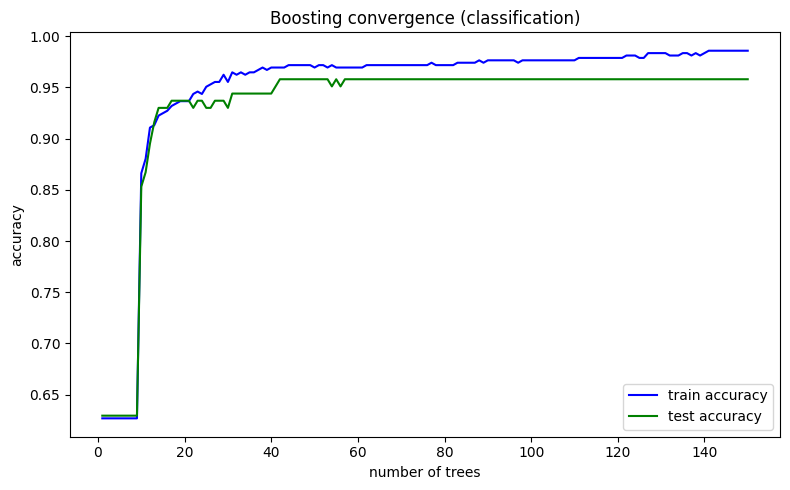

In [5]:
def staged_accuracy(model, X_tr, y_tr, X_te, y_te):
    y_tr_enc = np.searchsorted(model.classes_, y_tr)
    y_te_enc = np.searchsorted(model.classes_, y_te)
    raw_train = np.full(len(y_tr), model._initial_raw_score)
    raw_test = np.full(len(y_te), model._initial_raw_score)
    train_acc, test_acc = [], []
    for tree in model.trees:
        raw_train = raw_train + model.lr * tree.predict(X_tr)
        raw_test = raw_test + model.lr * tree.predict(X_te)
        train_acc.append(((model._sigmoid(raw_train) >= 0.5).astype(int) == y_tr_enc).mean())
        test_acc.append(((model._sigmoid(raw_test) >= 0.5).astype(int) == y_te_enc).mean())
    return train_acc, test_acc

train_acc, test_acc = staged_accuracy(gbc, Xc_train, yc_train, Xc_test, yc_test)
n_trees_clf = np.arange(1, len(train_acc) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_trees_clf, train_acc, color="b", label="train accuracy")
ax.plot(n_trees_clf, test_acc, color="g", label="test accuracy")

ax.set_xlabel("number of trees")
ax.set_ylabel("accuracy")
ax.set_title("Boosting convergence (classification)")

ax.legend()

plt.tight_layout()
plt.show()